In [33]:
import tensorflow as tf
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input

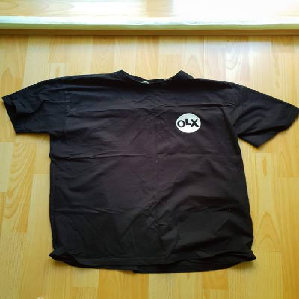

In [109]:
img_path = './train/t-shirt/'
img_name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'

img = load_img(img_path+img_name,target_size=(299,299))
img

In [110]:
x = np.array(img)

In [111]:
x.shape

(299, 299, 3)

In [112]:
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [113]:
X = preprocess_input(X)

In [114]:
model = Xception(weights='imagenet',input_shape=(299,299,3))

In [115]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [116]:
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.6819266)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03812331)),
  ('n04370456', 'sweatshirt', np.float32(0.03433772)),
  ('n03710637', 'maillot', np.float32(0.011362765)),
  ('n04525038', 'velvet', np.float32(0.0018474166))]]

## Transfer Learning

Pretrained model - Imagenet

- Read with ImageGenerator
- Train Xception

- Work with the vector representation from Imagenet, but not the dense layers
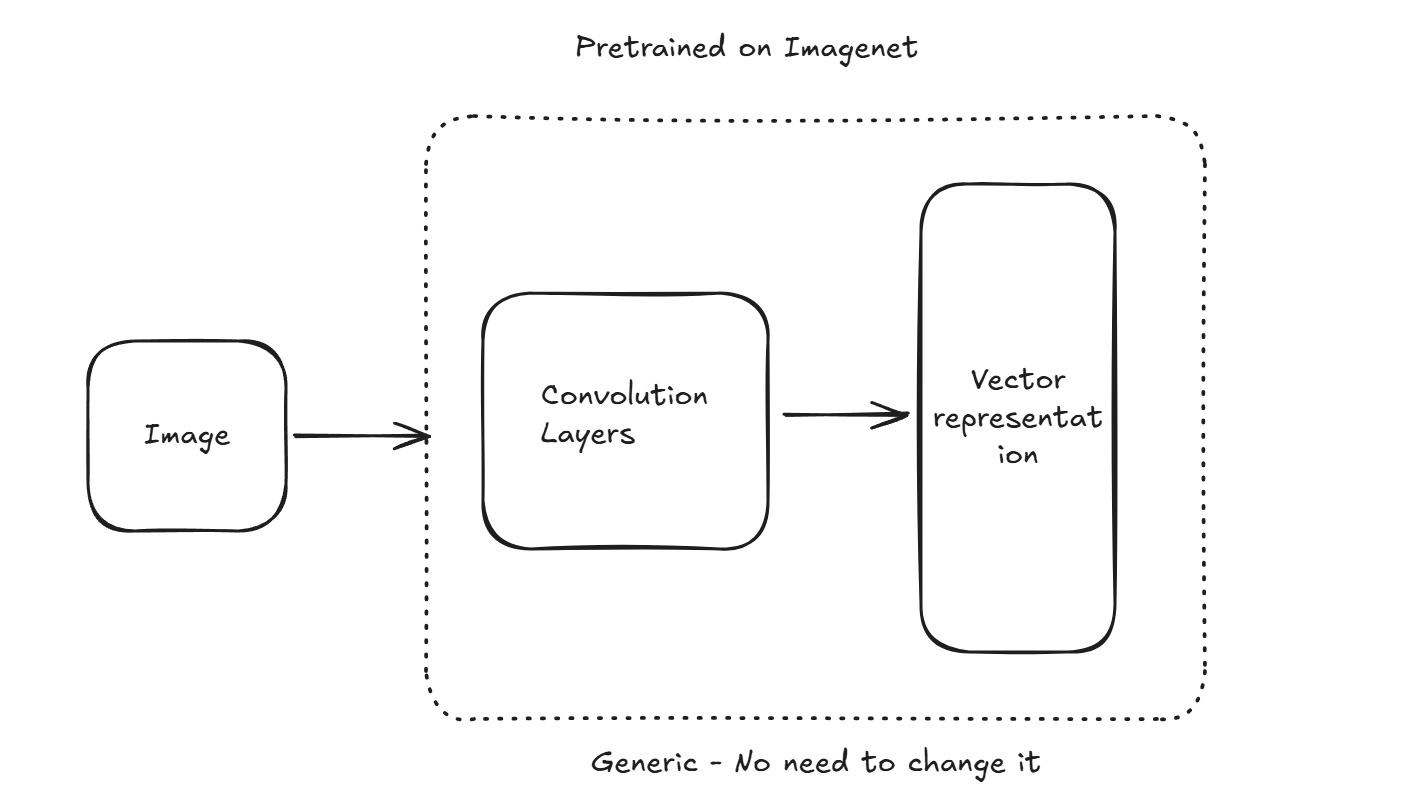

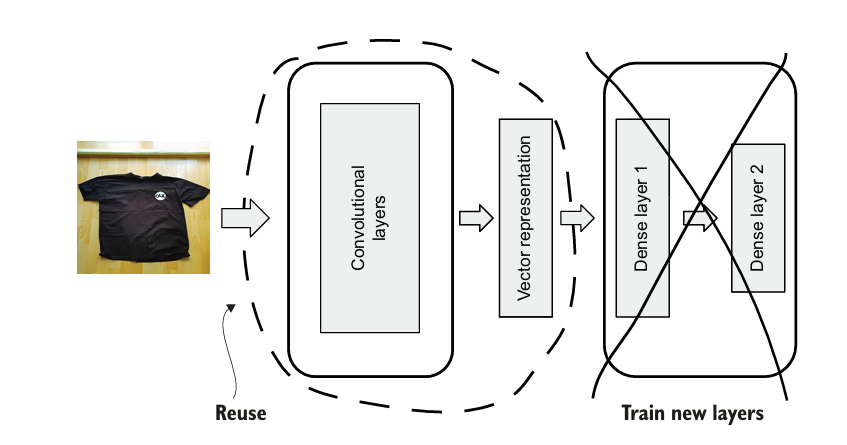

In [117]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [118]:
train_ds = train_gen.flow_from_directory(
    './train/',target_size=(150,150),batch_size=32
)

Found 3068 images belonging to 10 classes.


In [119]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [120]:
X,y = next(train_ds)

In [121]:
# X is representation of the batch of images
X.shape

(32, 150, 150, 3)

In [122]:
# y represents our target variable
"""
There are 10 classes
- When a value of 1 appears, then the target variable matches the class of the item
y[0] has 1 at possition 7, which corresponds with shorts

--> This is onehot encoding 
"""
y[:4]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [123]:
# Validation dataset
val_ds = val_gen.flow_from_directory(
    './validation/',
    target_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


### Train model
We train a custom model based off of a base model (Xception)
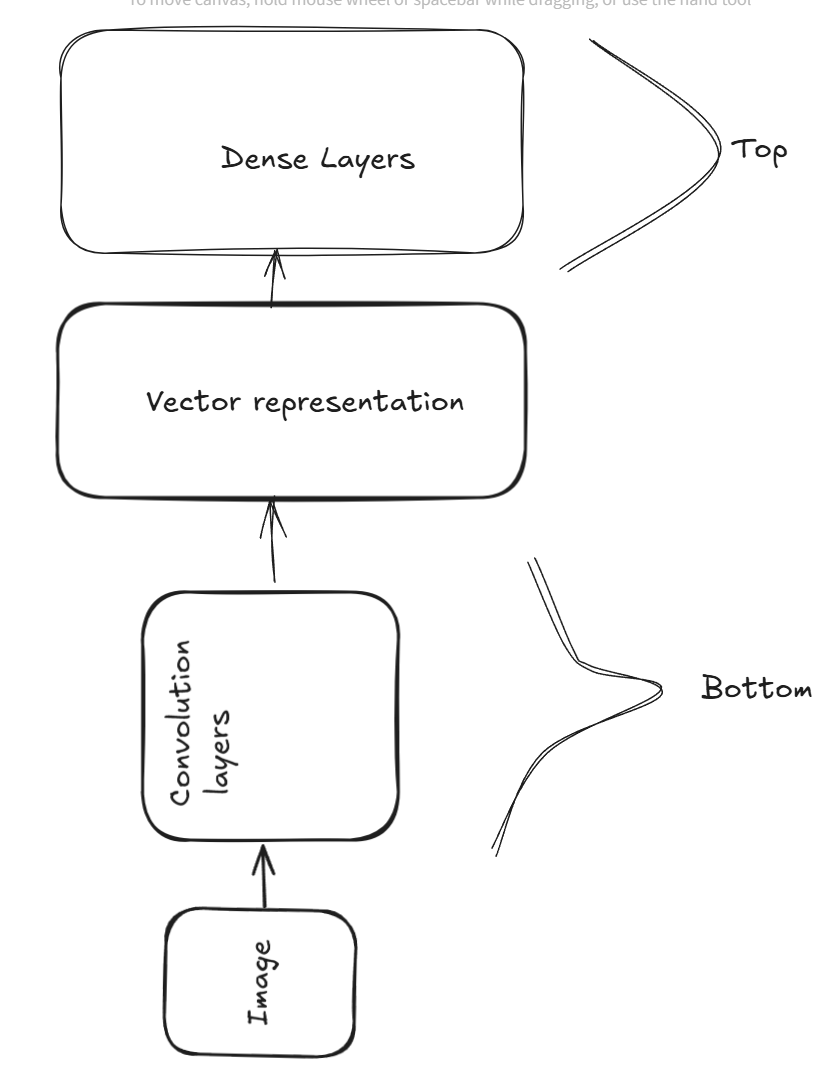

In [124]:
"""
We donot include the dense layers, hence include top false
Trainable is false because we do not want to train the convolution layers
"""

base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)
base_model.trainable = False

In [125]:
from tensorflow import keras

In [126]:
"""
Inputs are manipulated by base model to form base

Inputs = Batch of input Images

Outputs = Base, which is the Input manipulated by the Base Model

"""

inputs = keras.Input(shape=(150,150,3))
base = base_model(inputs)

outputs = base

model = keras.Model(inputs,outputs)

In [127]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [128]:
pred.shape

(32, 5, 5, 2048)

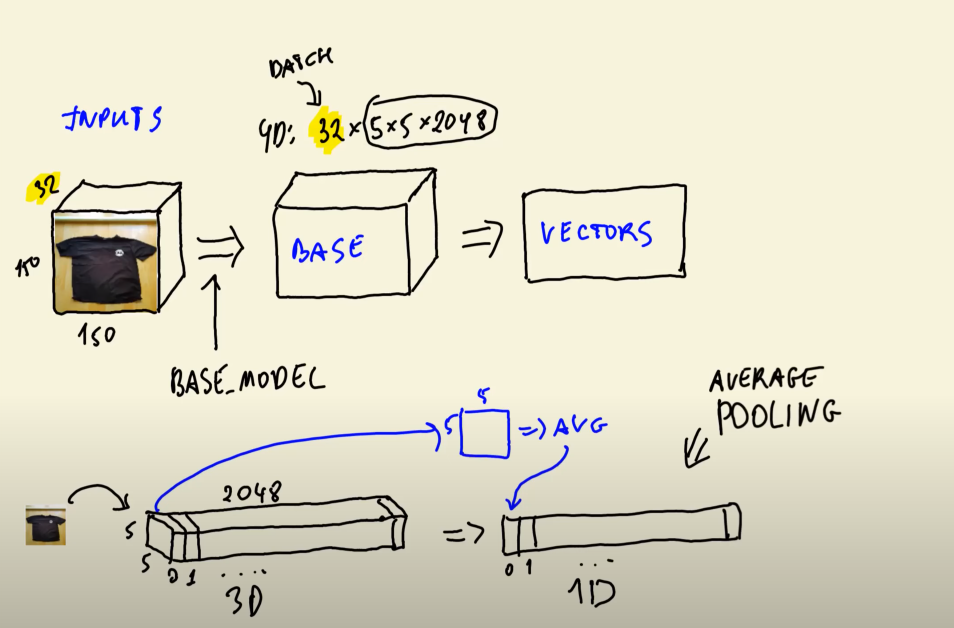

This diagram represents the **feature extraction process** of a Convolutional Neural Network (CNN), likely using a **pretrained model like Xception** with `include_top=False`. Here's what's happening step by step:

### **Step-by-Step Breakdown**
1. **Input Image (Bottom Left)**
   - The input is an image (e.g., a T-shirt), with dimensions **150x150**.
   - The batch size is **32**, meaning **32 images** are processed at once.

2. **Base Model (Feature Extractor)**
   - The input images pass through a **pretrained CNN model** (likely Xception, ResNet, or similar) without the classification head (`include_top=False`).
   - This outputs a **feature map** of shape **(32, 5, 5, 2048)**:
     - **32** → Batch size.
     - **5x5** → Spatial dimensions (reduced through convolution and pooling layers).
     - **2048** → Number of feature channels (high-level features extracted).

3. **Feature Vectors (Intermediate Representation)**
   - The **5x5x2048** feature maps are transformed into **feature vectors** for each image.
   - This vector represents the learned features of the input.

4. **Global Average Pooling (GAP)**
   - Instead of using fully connected (dense) layers, **Global Average Pooling** (GAP) is applied.
   - GAP takes each **5x5x2048** feature map and averages it across spatial dimensions, reducing it to a **1D vector of size 2048**.
   - This results in a final output shape: **(32, 2048)**.

### **Key Takeaways**
- The **Base Model** extracts important image features.
- Instead of flattening the output (which increases parameters), **Global Average Pooling** reduces it to a **2048-dimensional feature vector**.
- This vector can then be used for:
  - **Transfer learning** (fine-tuning a new model).

In [129]:
"""
We donot include the dense layers, hence include top false
Trainable is false because we do not want to train the convolution layers
"""
# Build base model
base_model = Xception(
    weights='imagenet',
    include_top=False, # to create a custom dense layer
    input_shape=(150,150,3)
)
base_model.trainable = False

In [130]:
# Manupulating earlier code
"""
After applying Global Avergae Pooling
- Each image in the batch is now represented as a 2048-dimensional vector.
- The feature vectors (32, 2048) are passed through a dense (fully connected) layer.
- This layer maps 2048 features → 10 output classes.
- The final output is (32, 10), meaning for each image, we get 10 class probabilities.
"""
# Define expected image shape as input
inputs = keras.Input(shape=(150,150,3))

# Feed inputs to the base model
base = base_model(inputs, training=False) # set False because the model contains BatchNormalization layer

# Convert matrices into vectors using pooling layer
vectors = keras.layers.GlobalAveragePooling2D()(base) 

# Create dense layer of 10 classes
outputs = keras.layers.Dense(10,activation='softmax')(vectors)

# Create model for training
model = keras.Model(inputs,outputs)

In [131]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [132]:
preds.shape  # Shrinked this to 1D

(32, 10)

## Train the model


In [133]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits=False)

In [134]:
model.compile(
    optimizer=optimizer,
    loss = loss,
    metrics = ["accuracy"]
)

In [135]:
# Epochs is the number of times we go over the dataset
history = model.fit(train_ds,epochs=10,validation_data = val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.5712 - loss: 1.8532 - val_accuracy: 0.7214 - val_loss: 0.9838
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8174 - loss: 0.5839 - val_accuracy: 0.7537 - val_loss: 0.9186
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9085 - loss: 0.2770 - val_accuracy: 0.7947 - val_loss: 0.7698
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9225 - loss: 0.2116 - val_accuracy: 0.8211 - val_loss: 0.7893
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9504 - loss: 0.1421 - val_accuracy: 0.7830 - val_loss: 0.8848
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9534 - loss: 0.1399 - val_accuracy: 0.8211 - val_loss: 0.8697
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9663 - loss: 0.0970 - val_accuracy: 0.7889 - val_loss: 0.9725
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9772 - loss: 0.0642 - val_accuracy: 0.8182 - 

In [139]:
history.history

{'accuracy': [0.658083438873291,
  0.8194263577461243,
  0.8943937420845032,
  0.9188396334648132,
  0.942307710647583,
  0.9566493034362793,
  0.9638200998306274,
  0.9778357148170471,
  0.9885919094085693,
  0.9921773076057434],
 'loss': [1.3753273487091064,
  0.5670264959335327,
  0.3121882677078247,
  0.228672057390213,
  0.16169659793376923,
  0.13218043744564056,
  0.10768198221921921,
  0.06734313070774078,
  0.04692705720663071,
  0.03366773948073387],
 'val_accuracy': [0.7214076519012451,
  0.7536656856536865,
  0.7947214245796204,
  0.8211143612861633,
  0.7829912304878235,
  0.8211143612861633,
  0.7888563275337219,
  0.8181818127632141,
  0.8064516186714172,
  0.8240469098091125],
 'val_loss': [0.9837946891784668,
  0.9186429381370544,
  0.7697700262069702,
  0.789282500743866,
  0.8847802877426147,
  0.8697277307510376,
  0.9725008010864258,
  0.8587205410003662,
  0.923888087272644,
  0.9346868991851807]}

In [140]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

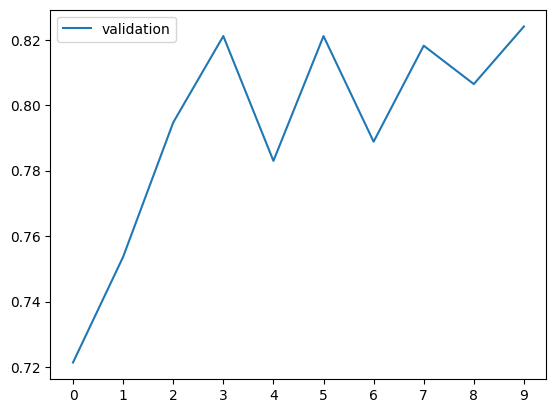

In [141]:
# plt.plot(train_accuracy,label='train')
plt.plot(val_accuracy,label='validation')
plt.xticks(np.arange(10))
plt.legend()

## Tuning Learning Rate

In [142]:
def define_model(learning_rate=0.01):
    """
    Build model
    """

    # Build base model
    base_model = Xception(
        weights='imagenet',
        include_top=False, # to create a custom dense layer
        input_shape=(150,150,3)
    )
    base_model.trainable = False

    """
    Define model architecture
    """
    # Define expected image shape as input
    inputs = keras.Input(shape=(150,150,3))    
    # Feed inputs to the base model
    base = base_model(inputs, training=False) # set False because the model contains BatchNormalization layer    
    # Convert matrices into vectors using pooling layer
    vectors = keras.layers.GlobalAveragePooling2D()(base)     
    # Create dense layer of 10 classes
    outputs = keras.layers.Dense(10,activation='softmax')(vectors)    
    # Create model for training
    model = keras.Model(inputs,outputs)

    """
    Train model
    """
    #create an optimizer
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    # Loss function definition
    loss = keras.losses.CategoricalCrossentropy(from_logits=False)

    model.compile(
    optimizer=optimizer,
    loss = loss,
    metrics = ["accuracy"]
    )
    
    return model

In [143]:
scores = {}

for lr in [0.005,0.009,0.001,0.01]:
    print("#########",lr)
    model = define_model(learning_rate=lr)
    history = model.fit(train_ds,epochs=10,validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

######### 0.005
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.6056 - loss: 1.2544 - val_accuracy: 0.7537 - val_loss: 0.7464
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8338 - loss: 0.4925 - val_accuracy: 0.8328 - val_loss: 0.5854
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8857 - loss: 0.3247 - val_accuracy: 0.7977 - val_loss: 0.6746
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9252 - loss: 0.2097 - val_accuracy: 0.7977 - val_loss: 0.6813
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9501 - loss: 0.1606 - val_accuracy: 0.8299 - val_loss: 0.6126
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9723 - loss: 0.1049 - val_accuracy: 0.8358 - val_loss: 0.6442
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9831 - loss: 0.0796 - val_accuracy: 0.8240 - val_loss: 0.6546
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9936 - loss: 0.0626 - val_acc

In [144]:
scores

{0.005: {'accuracy': [0.6877444386482239,
   0.829530656337738,
   0.8878748416900635,
   0.9243807196617126,
   0.9533898234367371,
   0.970664918422699,
   0.9833768010139465,
   0.9895697236061096,
   0.9941329956054688,
   0.9960886836051941],
  'loss': [0.956197202205658,
   0.483294278383255,
   0.32278206944465637,
   0.22482812404632568,
   0.1560748666524887,
   0.11219482868909836,
   0.0863754004240036,
   0.06977077573537827,
   0.055854979902505875,
   0.04660390317440033],
  'val_accuracy': [0.7536656856536865,
   0.8328445553779602,
   0.7976539731025696,
   0.7976539731025696,
   0.829912006855011,
   0.8357771039009094,
   0.8240469098091125,
   0.8093841671943665,
   0.8240469098091125,
   0.8211143612861633],
  'val_loss': [0.7463915348052979,
   0.5853985548019409,
   0.6745665669441223,
   0.6813392639160156,
   0.6126044392585754,
   0.6441715359687805,
   0.6546170115470886,
   0.6724758148193359,
   0.691216230392456,
   0.6965904831886292]},
 0.009: {'accuracy'

In [147]:
# del scores[1.0]
# del scores[0.0001]

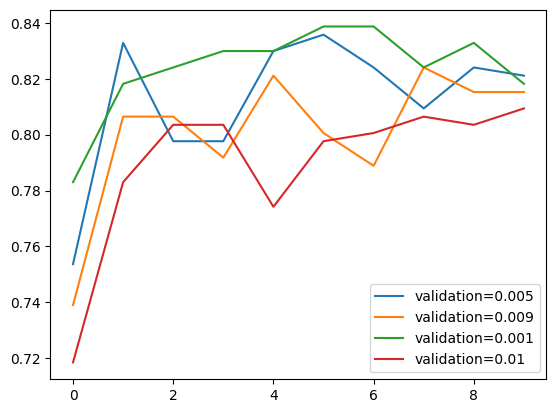

In [149]:
for lr,hist in scores.items():
    # print(lr)
    # print(hist)
    # plt.plot(hist['accuracy'],label=('train=%s'%lr))
    plt.plot(hist['val_accuracy'],label=('validation=%s'%lr))
    plt.legend()

## Checkpointing
- Save the best model
- Train a model with callbacks

In [150]:
model.save_weights('model_v1.weights.h5')

In [151]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [ ]:
# Best learning rate in this case will be 0.001
lr = 0.001
model = define_model(learning_rate=lr)
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint]    
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5104 - loss: 1.4532

96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.5117 - loss: 1.4494 - val_accuracy: 0.7889 - val_loss: 0.7036
Epoch 2/10
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7931 - loss: 0.6204

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.7930 - loss: 0.6205 - val_accuracy: 0.8270 - val_loss: 0.6129
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8385 - loss: 0.4844 - val_accuracy: 0.8123 - val_loss: 0.5911
Epoch 4/10
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8610 - loss: 0.4249

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8611 - loss: 0.4248 - val_accuracy: 0.8328 - val_loss: 0.5400
Epoch 5/10
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8955 - loss: 0.3600

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8954 - loss: 0.3602 - val_accuracy: 0.8358 - val_loss: 0.5251
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9119 - loss: 0.3120 - val_accuracy: 0.8123 - val_loss: 0.5424
Epoch 7/10
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9273 - loss: 0.2705

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9272 - loss: 0.2708 - val_accuracy: 0.8416 - val_loss: 0.5227
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9363 - loss: 0.2566 - val_accuracy: 0.8387 - val_loss: 0.5152
Epoch 9/10
 9/96 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9630 - loss: 0.1745

## Adding more layers

In [42]:
def define_model_with_dense_inner(learning_rate=0.01,inner_size=100):
    """
    Build model
    """

    # Build base model
    base_model = Xception(
        weights='imagenet',
        include_top=False, # to create a custom dense layer
        input_shape=(150,150,3)
    )
    base_model.trainable = False

    """
    Define model architecture
    """
    # Define expected image shape as input
    inputs = keras.Input(shape=(150,150,3))    
    # Feed inputs to the base model
    base = base_model(inputs, training=False) # set False because the model contains BatchNormalization layer    
    # Convert matrices into vectors using pooling layer
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner = keras.layers.Dense(inner_size,activation='relu')(vectors)  
    # Create dense layer of 10 classes
    outputs = keras.layers.Dense(10)(inner)    
    # Create model for training
    model = keras.Model(inputs,outputs)

    """
    Train model
    """
    #create an optimizer
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    # Loss function definition
    """
    When from_logits=True is set in CategoricalCrossentropy, the softmax activation is implicitly applied by the loss function.
    Adding a softmax activation explicitly in this case would lead to incorrect behavior and poor training performance.
    Using from_logits=True is preferred for numerical stability and efficiency. If you want to add softmax explicitly, 
    you must set from_logits=False.
    """
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
    optimizer=optimizer,
    loss = loss,
    metrics = ["accuracy"]
    )
    
    return model

In [45]:
scores = {}
for size in [200,500,100,1000]:
    print(f"######################{size}")
    lr = 0.001
    model = define_model_with_dense_inner(learning_rate=lr,inner_size=size)
    history = model.fit(train_ds,epochs=10,validation_data=val_ds)
    scores[size] = history.history    

######################10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 200ms/step - accuracy: 0.4179 - loss: 1.7524 - val_accuracy: 0.6364 - val_loss: 1.1195
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - accuracy: 0.6812 - loss: 0.9969 - val_accuracy: 0.7273 - val_loss: 0.8349
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - accuracy: 0.7451 - loss: 0.7599 - val_accuracy: 0.7331 - val_loss: 0.7560
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.7873 - loss: 0.6364 - val_accuracy: 0.7713 - val_loss: 0.6757
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.8236 - loss: 0.5517 - val_accuracy: 0.7889 - val_loss: 0.6300
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.8571 - loss: 0.4565 - val_accuracy: 0.7801 - val_loss: 0.6532
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.8729 - loss: 0.3931 - val_accuracy: 0.8006 - val_loss: 0.6225
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.8960 

2025-03-14 08:48:37.941422: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3765', 220 bytes spill stores, 592 bytes spill loads

2025-03-14 08:48:38.270096: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3772', 148 bytes spill stores, 148 bytes spill loads

2025-03-14 08:48:38.298048: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3772', 516 bytes spill stores, 516 bytes spill loads

2025-03-14 08:48:38.373611: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3765', 232 bytes spill stores, 232 bytes spill loads



17/96 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.3440 - loss: 3.8031

2025-03-14 08:48:44.253553: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3765', 16 bytes spill stores, 16 bytes spill loads

2025-03-14 08:48:44.291321: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3765', 168 bytes spill stores, 168 bytes spill loads

2025-03-14 08:48:44.758831: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3765', 240 bytes spill stores, 240 bytes spill loads

2025-03-14 08:48:45.183672: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3772', 92 bytes spill stores, 92 bytes spill loads

2025-03-14 08:48:45.580060: I external/local_xla/xla/str

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5710 - loss: 1.9774 

2025-03-14 08:49:02.648794: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1058', 240 bytes spill stores, 240 bytes spill loads

2025-03-14 08:49:02.791166: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1058', 56 bytes spill stores, 56 bytes spill loads

2025-03-14 08:49:02.847741: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1058', 16 bytes spill stores, 16 bytes spill loads

2025-03-14 08:49:03.212884: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1065', 92 bytes spill stores, 92 bytes spill loads

2025-03-14 08:49:03.244953: I external/local_xla/xla/strea

96/96 ━━━━━━━━━━━━━━━━━━━━ 32s 251ms/step - accuracy: 0.5721 - loss: 1.9691 - val_accuracy: 0.7419 - val_loss: 0.7364
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.8233 - loss: 0.4868 - val_accuracy: 0.8065 - val_loss: 0.5811
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.9010 - loss: 0.2902 - val_accuracy: 0.8006 - val_loss: 0.6777
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.9403 - loss: 0.1845 - val_accuracy: 0.8328 - val_loss: 0.5811
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.9722 - loss: 0.0973 - val_accuracy: 0.8006 - val_loss: 0.6924
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.9841 - loss: 0.0511 - val_accuracy: 0.7947 - val_loss: 0.8262
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.9798 - loss: 0.0752 - val_accuracy: 0.8123 - val_loss: 0.7583
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.9804 - loss: 0.0537 - val_accuracy: 0.815

In [49]:
scores

{10: {'accuracy': [0.5058670043945312,
   0.6818774342536926,
   0.7441329956054688,
   0.7878096699714661,
   0.8239895701408386,
   0.849413275718689,
   0.8679921627044678,
   0.8878748416900635,
   0.9061277508735657,
   0.924054741859436],
  'loss': [1.4741264581680298,
   0.9449824690818787,
   0.7545299530029297,
   0.6293696761131287,
   0.5333607792854309,
   0.46457594633102417,
   0.41112035512924194,
   0.3602863848209381,
   0.3172342777252197,
   0.2811790704727173],
  'val_accuracy': [0.6363636255264282,
   0.7272727489471436,
   0.733137845993042,
   0.7712609767913818,
   0.7888563275337219,
   0.7800586223602295,
   0.8005865216255188,
   0.8064516186714172,
   0.8064516186714172,
   0.7976539731025696],
  'val_loss': [1.119490146636963,
   0.8349027633666992,
   0.7560262680053711,
   0.6757018566131592,
   0.6300287246704102,
   0.6531809568405151,
   0.6225323677062988,
   0.5954431295394897,
   0.586811900138855,
   0.5900771617889404]},
 100: {'accuracy': [0.6789

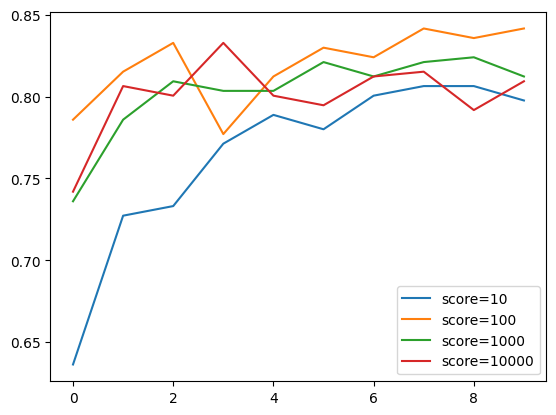

In [55]:
for score, hist in scores.items():
    # plt.plot(hist['accuracy'],label=("score=%s"%score))
    plt.plot(hist['val_accuracy'],label=("score=%s"%score))
    plt.legend()

In [37]:
!nvidia-smi

Fri Mar 14 08:30:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.04             Driver Version: 572.61         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   45C    P8             13W /  100W |     448MiB /   6144MiB |     14%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Regularization and Dropout

- Regularization 0 Free a part of the network
- Add dropout to our model
- Experiment with different values

In [61]:
def define_model_with_dense_inner(learning_rate=0.01,inner_size=100,drop_rate=0.1):
    """
    Build model
    """

    # Build base model
    base_model = Xception(
        weights='imagenet',
        include_top=False, # to create a custom dense layer
        input_shape=(150,150,3)
    )
    base_model.trainable = False

    """
    Define model architecture
    """
    # Define expected image shape as input
    inputs = keras.Input(shape=(150,150,3))    
    # Feed inputs to the base model
    base = base_model(inputs, training=False) # set False because the model contains BatchNormalization layer    
    # Convert matrices into vectors using pooling layer
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner = keras.layers.Dense(inner_size,activation='relu')(vectors) 

    dropout = keras.layers.Dropout(rate=drop_rate)(inner)
    
    # Create dense layer of 10 classes
    outputs = keras.layers.Dense(10)(dropout)    
    # Create model for training
    model = keras.Model(inputs,outputs)

    """
    Train model
    """
    #create an optimizer
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    # Loss function definition
    """
    When from_logits=True is set in CategoricalCrossentropy, the softmax activation is implicitly applied by the loss function.
    Adding a softmax activation explicitly in this case would lead to incorrect behavior and poor training performance.
    Using from_logits=True is preferred for numerical stability and efficiency. If you want to add softmax explicitly, 
    you must set from_logits=False.
    """
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
    optimizer=optimizer,
    loss = loss,
    metrics = ["accuracy"]
    )
    
    return model

In [65]:
scores = {}
for droprate in [0.0,0.1,0.2,0.5,0.8,0.9]:
    print(f"######################{droprate}")
    lr = 0.001
    size = 100
    model = define_model_with_dense_inner(learning_rate=lr,inner_size=size,drop_rate=droprate)
    history = model.fit(train_ds,epochs=30,validation_data=val_ds)
    scores[droprate] = history.history    

######################0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 34s 261ms/step - accuracy: 0.5688 - loss: 1.2876 - val_accuracy: 0.8094 - val_loss: 0.5916
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.8300 - loss: 0.4898 - val_accuracy: 0.7947 - val_loss: 0.5800
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - accuracy: 0.8856 - loss: 0.3630 - val_accuracy: 0.8240 - val_loss: 0.5373
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.9335 - loss: 0.2374 - val_accuracy: 0.8065 - val_loss: 0.5245
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - accuracy: 0.9597 - loss: 0.1621 - val_accuracy: 0.8270 - val_loss: 0.5295
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.9712 - loss: 0.1353 - val_accuracy: 0.8299 - val_loss: 0.5492
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.9865 - loss: 0.0794 - val_accuracy: 0.8094 - val_loss: 0.6249
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.9844

In [66]:
scores

{0.0: {'accuracy': [0.6632985472679138,
   0.8252933621406555,
   0.8810299634933472,
   0.9250326156616211,
   0.9524120092391968,
   0.9670795202255249,
   0.9827249050140381,
   0.9908735156059265,
   0.9973924160003662,
   0.9990221858024597,
   0.9993481040000916,
   0.9996740818023682,
   0.9996740818023682,
   0.9986962080001831,
   0.9996740818023682,
   0.9996740818023682,
   0.9980443120002747,
   0.9996740818023682,
   0.9993481040000916,
   0.9996740818023682,
   0.9990221858024597,
   0.9996740818023682,
   0.9986962080001831,
   0.9977183938026428,
   0.9986962080001831,
   0.9833768010139465,
   0.9432855248451233,
   0.9850065112113953,
   0.9970664978027344,
   0.9993481040000916],
  'loss': [0.9904955625534058,
   0.49626708030700684,
   0.3604895770549774,
   0.2511647939682007,
   0.17803308367729187,
   0.13784921169281006,
   0.08366896212100983,
   0.06448493897914886,
   0.04134022817015648,
   0.030787544324994087,
   0.022581864148378372,
   0.0177454389631748

In [82]:
# del scores[0.9]
# del scores[0.8]
del scores[0.1]

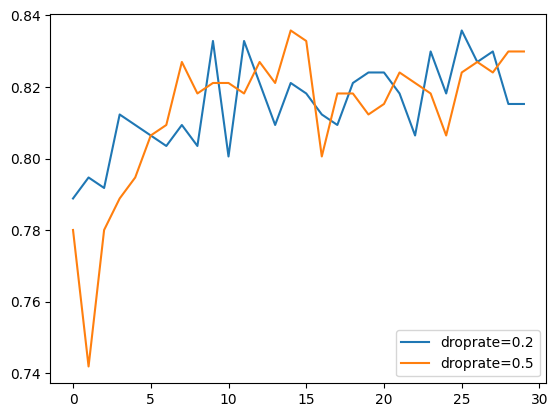

In [83]:
for rate, hist in scores.items():
    # plt.plot(hist['accuracy'],label=("score=%s"%score))
    plt.plot(hist['val_accuracy'],label=("droprate=%s"%rate))
    plt.legend()

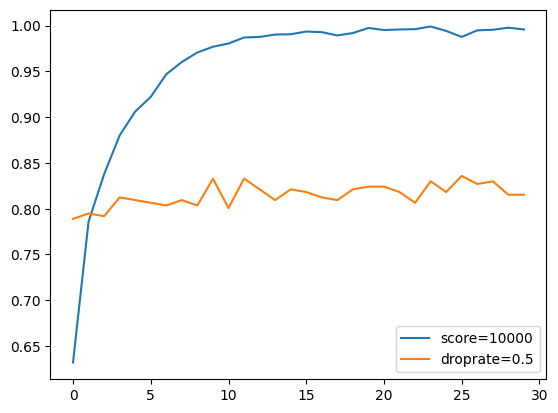

In [84]:
hist = scores[0.2]
plt.plot(hist['accuracy'],label=("score=%s"%score))
plt.plot(hist['val_accuracy'],label=("droprate=%s"%rate))
# plt.ylim(0.75,0.86)
plt.legend()

In [104]:
def define_model_with_dense_inner(learning_rate=0.001,inner_size=100,drop_rate=0.2):
    """
    Build model
    """

    # Build base model
    base_model = Xception(
        weights='imagenet',
        include_top=False, # to create a custom dense layer
        input_shape=(150,150,3)
    )
    base_model.trainable = False

    """
    Define model architecture
    """
    # Define expected image shape as input
    inputs = keras.Input(shape=(150,150,3))    
    # Feed inputs to the base model
    base = base_model(inputs, training=False) # set False because the model contains BatchNormalization layer    
    # Convert matrices into vectors using pooling layer
    vectors = keras.layers.GlobalAveragePooling2D()(base)
        
    inner_layer = keras.layers.Dense(inner_size,activation='relu')(vectors) 
    
    droprate = keras.layers.Dropout(rate=drop_rate)(inner_layer)
    
    # Create dense layer of 10 classes
    outputs = keras.layers.Dense(10)(droprate)    
    # Create model for training
    model = keras.Model(inputs,outputs)

    """
    Train model
    """
    #create an optimizer
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    # Loss function definition
    """
    When from_logits=True is set in CategoricalCrossentropy, the softmax activation is implicitly applied by the loss function.
    Adding a softmax activation explicitly in this case would lead to incorrect behavior and poor training performance.
    Using from_logits=True is preferred for numerical stability and efficiency. If you want to add softmax explicitly, 
    you must set from_logits=False.
    """
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
    optimizer=optimizer,
    loss = loss,
    metrics = ["accuracy"]
    )
    
    return model

In [105]:
model = define_model_with_dense_inner()
history = model.fit(train_ds,epochs=30,validation_data=val_ds)
scores[droprate] = history.history    

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 62s 297ms/step - accuracy: 0.5516 - loss: 1.3496 - val_accuracy: 0.7801 - val_loss: 0.6807
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 173ms/step - accuracy: 0.7915 - loss: 0.6284 - val_accuracy: 0.7918 - val_loss: 0.6374
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.8486 - loss: 0.4543 - val_accuracy: 0.8270 - val_loss: 0.5661
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - accuracy: 0.8846 - loss: 0.3348 - val_accuracy: 0.8328 - val_loss: 0.5508
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - accuracy: 0.9203 - loss: 0.2626 - val_accuracy: 0.8240 - val_loss: 0.5894
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 168ms/step - accuracy: 0.9298 - loss: 0.2254 - val_accuracy: 0.8094 - val_loss: 0.5772
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - accuracy: 0.9495 - loss: 0.1813 - val_accuracy: 0.8299 - val_loss: 0.5889
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.9634 - loss: 0.1377 - val_accu

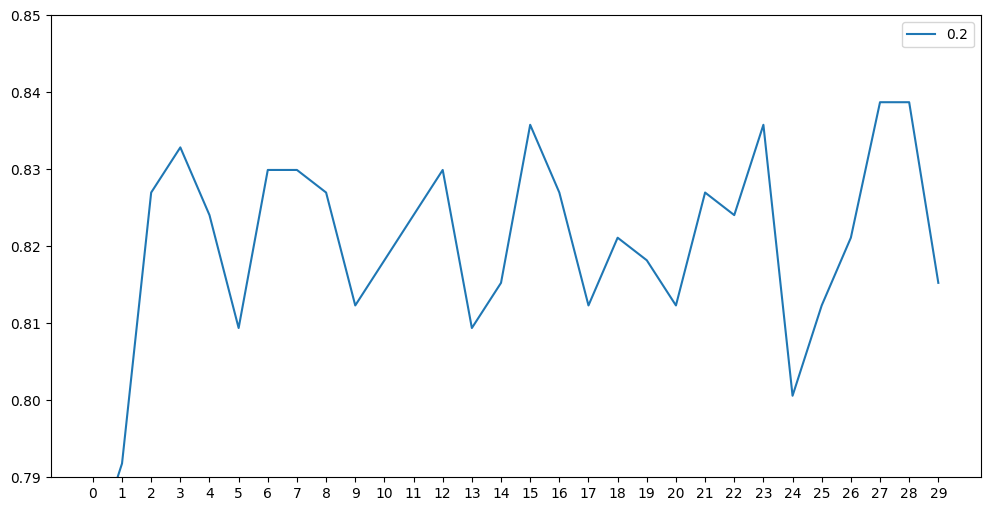

In [107]:
# plt.plot(history.history['accuracy'], label=0.5)
plt.figure(figsize=(12,6))
plt.plot(history.history['val_accuracy'],label=0.2)
plt.ylim(0.79,0.85)
plt.xticks(np.arange(0,30))
plt.legend()


## Data Augmentation
Image augmentation is a technique of applying different transformations to original images which results in multiple transformed copies of the same image. Each copy, however, is different from the other in certain aspects depending on the augmentation techniques you apply like shifting, rotating, flipping, etc.

In [102]:
train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=30.0,
    height_shift_range=30.0,
    shear_range=10.0,
    zoom_range=0.1,
    horizontal_flip=True,
)

In [103]:
val_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_dataset = val_generator.flow_from_directory(
    "validation/",
    batch_size=32,
    target_size=(150,150),
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [104]:
train_dataset = train_generator.flow_from_directory(
    "train/",
    target_size=(150,150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [105]:
def augumented_model(learning_rate=0.001,inner_size=100,drop_rate=0.2):
    """
    Build model
    """

    # Build base model
    base_model = Xception(
        weights='imagenet',
        include_top=False, # to create a custom dense layer
        input_shape=(150,150,3)
    )
    base_model.trainable = False

    """
    Define model architecture
    """
    # Define expected image shape as input
    inputs = keras.Input(shape=(150,150,3))    
    # Feed inputs to the base model
    base = base_model(inputs, training=False) # set False because the model contains BatchNormalization layer    
    # Convert matrices into vectors using pooling layer
    vectors = keras.layers.GlobalAveragePooling2D()(base)
        
    inner_layer = keras.layers.Dense(inner_size,activation='relu')(vectors) 
    
    droprate = keras.layers.Dropout(rate=drop_rate)(inner_layer)
    
    # Create dense layer of 10 classes
    outputs = keras.layers.Dense(10)(droprate)    
    # Create model for training
    model = keras.Model(inputs,outputs)

    """
    Train model
    """
    #create an optimizer
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    # Loss function definition
    """
    When from_logits=True is set in CategoricalCrossentropy, the softmax activation is implicitly applied by the loss function.
    Adding a softmax activation explicitly in this case would lead to incorrect behavior and poor training performance.
    Using from_logits=True is preferred for numerical stability and efficiency. If you want to add softmax explicitly, 
    you must set from_logits=False.
    """
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
    optimizer=optimizer,
    loss = loss,
    metrics = ["accuracy"]
    )
    
    return model

In [106]:
model = augumented_model()
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset
)

/home/rogue-one/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 167ms/step - accuracy: 0.5272 - loss: 1.4016 - val_accuracy: 0.7742 - val_loss: 0.6929
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.7666 - loss: 0.6975 - val_accuracy: 0.7947 - val_loss: 0.6465
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.7921 - loss: 0.6069 - val_accuracy: 0.7625 - val_loss: 0.6707
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.8180 - loss: 0.5180 - val_accuracy: 0.8065 - val_loss: 0.5811
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.8435 - loss: 0.4534 - val_accuracy: 0.7889 - val_loss: 0.5788
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.8557 - loss: 0.4310 - val_accuracy: 0.8152 - val_loss: 0.5402
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.8680 - loss: 0.3807 - val_accuracy: 0.8006 - val_loss: 0.5861
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.8815 - loss: 0.3329 - val_accu

In [107]:
hist = history.history

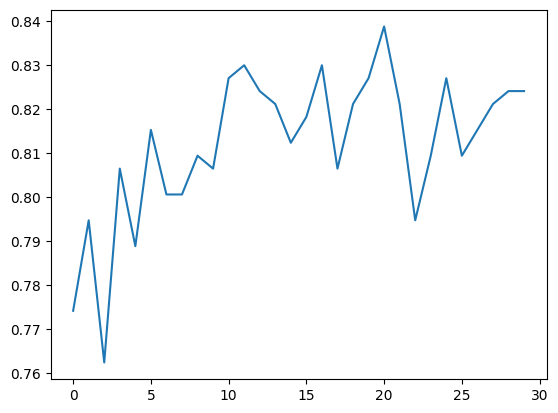

In [108]:
plt.plot(hist['val_accuracy'])